# Session8
Today we are going to learn how to analysis multi-dimensional data by analyzing fMRI dataset with `nibabel` and `seaborn`

## fMRI Data
we can check MRI data (images) just using python!

In [1]:
from matplotlib import pyplot
import nibabel
import pandas
import seaborn
import numpy
import scipy.signal

In [2]:
pwd

'/home/shch14/spaceMed2026/shch14/notebook'

### Just MRI data for building anatomy

In [3]:
anatomy = nibabel.load("../fmri-data/2_Anatomy_1mm_5min.nii")

In [4]:
print(anatomy.header) #quickly check the dataset

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 192 256 256   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.       1.       0.976562 0.976562 2.3      0.       0.       0.      ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=2.3;Time=170738.945'
aux_file        : b''
qform_code      : scanner
sform_code      : scanner
quatern_b       : -0.027891552075743675
quatern_c       : 0.006216157227754593
quatern_d       : -0.0195028111338615

In [5]:
print(anatomy.shape) #it will show the dataset is 3D and how many slices we have

(192, 256, 256)


In [6]:
print(anatomy.header.get_zooms())

(np.float32(1.0), np.float32(0.976562), np.float32(0.976562))


In [7]:
data_anatomy = anatomy.get_fdata() # extract data

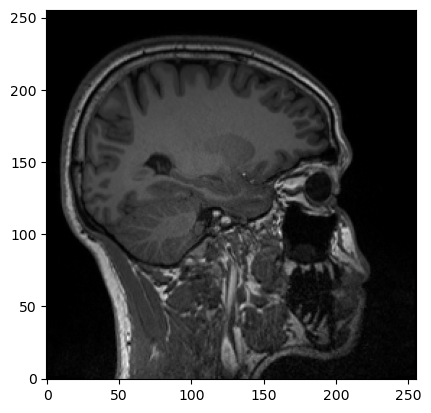

In [8]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[120, :, :].T, # .T means transportation 
    origin="lower", # origin tells the vertical orientation
    cmap="gray")

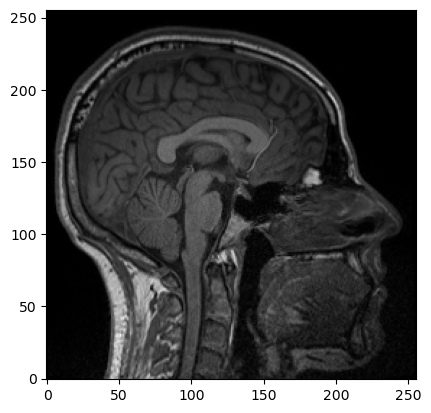

In [9]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[96, :, :].T, # change to different slice
    origin="lower", 
    cmap="gray")

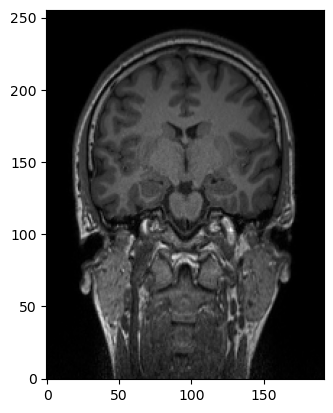

In [10]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[:, 120, :].T, 
    origin="lower",
    cmap="gray")

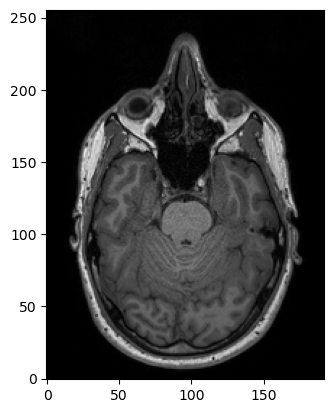

In [11]:
fig, axes = pyplot.subplots(1)
axes.imshow(data_anatomy[:, :, 120].T, 
    origin="lower",
    cmap="gray")

If we have different datasets then we have to map them together.
In this condition, we use `.affine` to do the transformation  (rotate and translate)

In [12]:
print(anatomy.affine) # I have dataset called anatomy
# another dataset called fmri: print(fmri.affine)

[[ 9.99162018e-01  3.77299786e-02  1.31960846e-02 -9.83170929e+01]
 [-3.93290296e-02  9.74299788e-01  5.42062148e-02 -1.24112167e+02]
 [-1.13369459e-02 -5.46798818e-02  9.74967122e-01 -1.17133888e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Run correlation

We have to learn how to run correlation in python first

In [13]:
ols = pandas.read_csv("../data/ols.csv")

In [14]:
ols

,Vehicle,Length (m),Payload Mass to LEO (kg),Origin,First Flight,Initial Mass (kg)
0,Falcon 9,70.00,22800,USA,2010.0,549000
1,Falcon Heavy,70.00,63800,USA,2018.0,1420000
2,Atlas V,62.50,13550,USA,2002.0,335000
3,Delta IV Heavy,72.00,28370,USA,2002.0,733000
4,SLS Block 1,98.00,95000,USA,2022.0,2600000
5,Starship,120.00,125000,USA,2024.0,5000000
6,Vulcan Centaur,61.00,27200,USA,2023.0,540000
7,Electron,18.00,300,USA,2015.0,12500
8,New Glenn,98.00,45000,USA,2021.0,862000
9,Saturn V,110.60,140000,USA,1967.0,3000000


<Axes: xlabel='Initial Mass (kg)', ylabel='Payload Mass to LEO (kg)'>

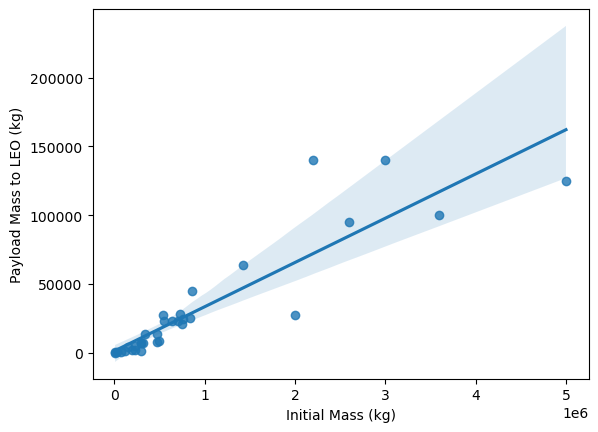

In [15]:
# run correlation
seaborn.regplot(
    ols,
    x='Initial Mass (kg)',
    y='Payload Mass to LEO (kg)',
    order=1)

<Axes: xlabel='Length (m)', ylabel='Payload Mass to LEO (kg)'>

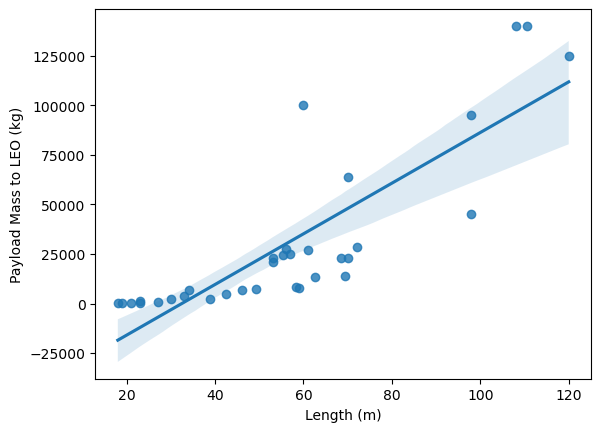

In [16]:
seaborn.regplot(
    ols,
    x='Length (m)',
    y='Payload Mass to LEO (kg)',
    order=1)

<Axes: xlabel='Length (m)', ylabel='Payload Mass to LEO (kg)'>

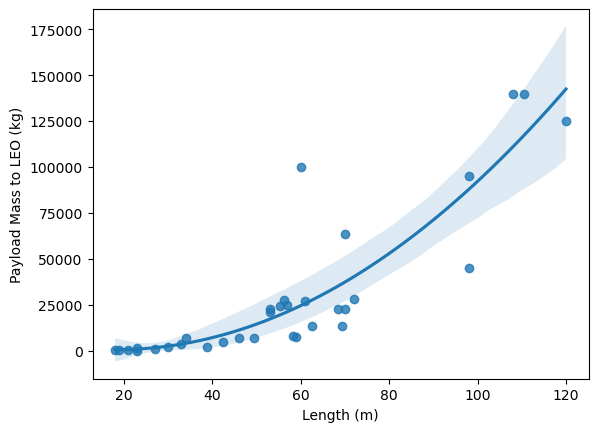

In [17]:
seaborn.regplot(
    ols,
    x='Length (m)',
    y='Payload Mass to LEO (kg)',
    order=2) # change the order to make the prediction fit the data  

**Now go back to fMRI Data!**

In [18]:
fmri = nibabel.load("../fmri-data/3_fMRI_TR2sec_3mm_3min.nii")

In [19]:
fmri.shape

(64, 64, 32, 80)

In [20]:
print(fmri.header.get_zooms())

(np.float32(3.0), np.float32(3.0), np.float32(3.75), np.float32(2.0))


In [21]:
nt = fmri.shape[-1]

In [22]:
sampling_rate = fmri.header.get_zooms()[-1]

In [23]:
print(nt, sampling_rate)

80 2.0


In [24]:
p1 = (19,24,25) # assign what I want to extract
p2 = (40,25,25)
p3 = (19,25,25)

In [25]:
fmri_data = fmri.get_fdata() # get data from the dataset

In [26]:
fmri_data[p1]

array([406., 403., 433., 477., 506., 511., 514., 522., 515., 496., 454.,
       435., 435., 457., 466., 475., 476., 477., 461., 431., 425., 417.,
       441., 471., 487., 495., 501., 503., 479., 432., 376., 362., 414.,
       460., 465., 473., 471., 476., 455., 408., 385., 386., 410., 460.,
       482., 501., 510., 498., 464., 420., 429., 406., 410., 455., 475.,
       491., 481., 457., 455., 415., 402., 386., 419., 452., 479., 484.,
       482., 476., 447., 403., 380., 376., 414., 468., 491., 488., 488.,
       495., 495., 475.])

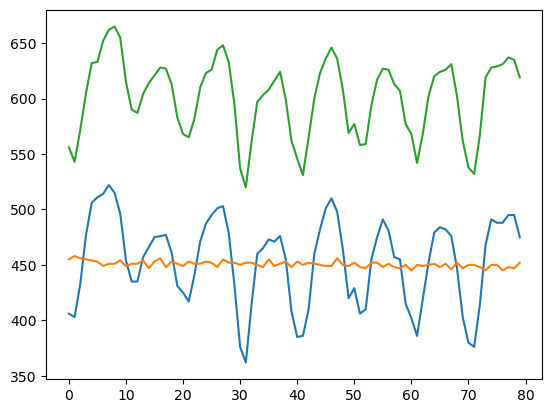

In [27]:
pyplot.plot(fmri_data[p1])
pyplot.plot(fmri_data[p2])
pyplot.plot(fmri_data[p3])

In [28]:
# since the sampling rate is 2 seconds, and the setting is 10s on and 10s off
# we need 5 datapoints for each condition
s_one = numpy.array([1]*5 + [0]*5)

In [29]:
s_one

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

In [30]:
#use tile we can pile up our array based on the times we assign 
numpy.tile(s_one,2) # 2 means we want 20-second block

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

In [31]:
# since we use 10s as unit, we repeated ceiling of nt/10 to cover all the datapoints
signal = numpy.tile(s_one, int(numpy.ceil(nt/10)))

In [32]:
signal = signal[:nt]

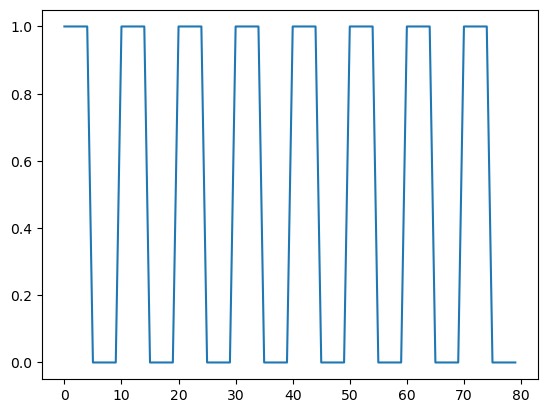

In [33]:
pyplot.plot(signal)

In [34]:
# make a function for normalizing data
def normalise(data):
    norm = (data - numpy.mean(data))
    norm = norm / numpy.std(data)
    return norm

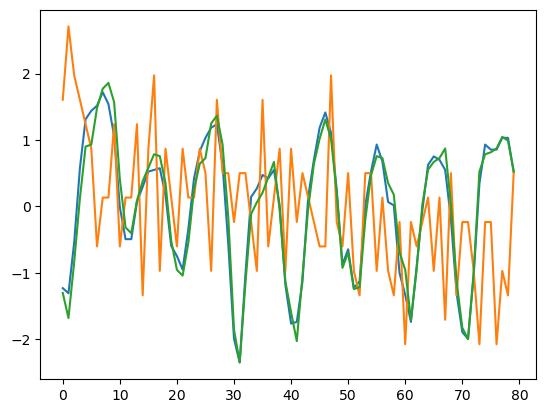

In [35]:
pyplot.plot(normalise(fmri_data[p1]))
pyplot.plot(normalise(fmri_data[p2])) # the orange one is like noise
pyplot.plot(normalise(fmri_data[p3]))

In [36]:
freq, power = scipy.signal.periodogram(normalise(fmri_data[p1]),
                                      fs=1/sampling_rate)
#freqency consent with time series to show the distribution
#it's a kind of FFT

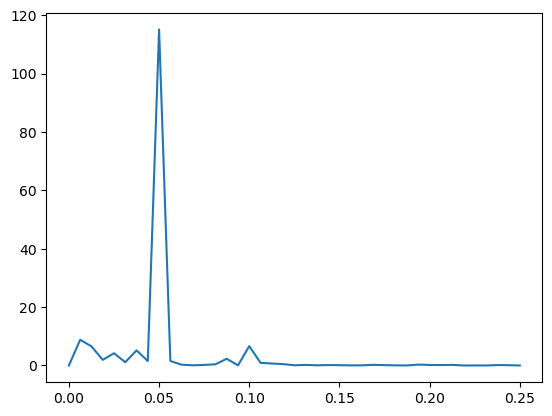

In [37]:
pyplot.plot(freq,power)

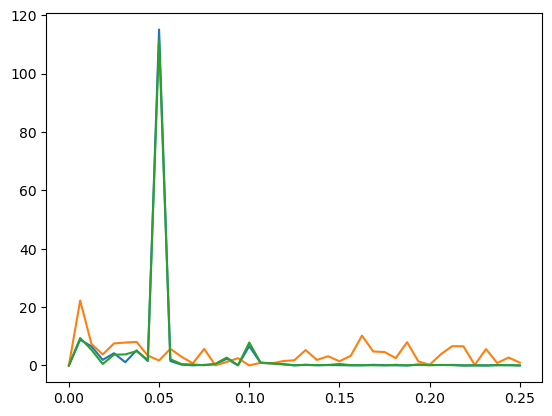

In [38]:
# now let's run each frequency with loop
for p in (p1, p2, p3):
    freq, power = scipy.signal.periodogram(normalise(fmri_data[p]),
                                      fs=1/sampling_rate)
    pyplot.plot(freq,power)

In [39]:
# right now try to overlap the signal together -- cross correlation
# do p1 first
data = fmri_data[p1]
cross = scipy.signal.correlate(
    normalise(data), normalise(signal),
    mode="same")
lags = scipy.signal.correlation_lags(
    len(data), len(signal),
    mode="same")

In [40]:
p = numpy.argmax(cross)

In [41]:
lags[p] # peaks is at 8 seconds (something happened here)

np.int64(4)

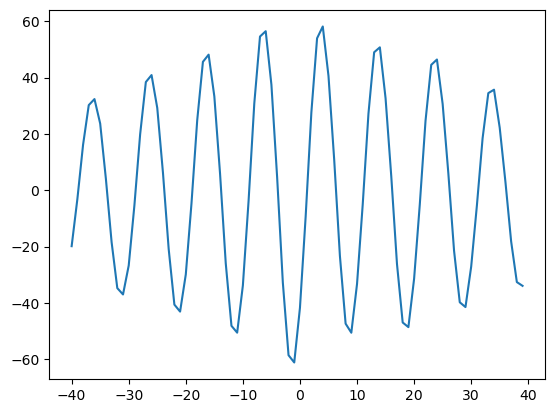

In [42]:
pyplot.plot(lags, cross)

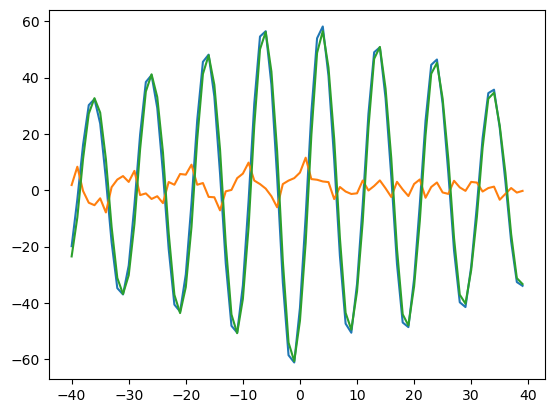

In [43]:
# let's run for loop again
for p in (p1,p2,p3):
    data = fmri_data[p]
    cross = scipy.signal.correlate(
        normalise(data), normalise(signal),
        mode="same")
    lags = scipy.signal.correlation_lags(
        len(data), len(signal),
        mode="same")
    pyplot.plot(lags, cross)

# we can successfully filter out noise now

In [44]:
corr_map = numpy.zeros(fmri.shape[:2]) #create 2D array

In [45]:
z = 25 #z as slice index

In [48]:
#align with time series 
for x in range(corr_map.shape[0]):
    for y in range(corr_map.shape[1]):
        time_series = fmri_data[x,y,z, :]
        cross = scipy.signal.correlate(
            normalise(time_series), 
            normalise(signal), 
            mode="same")
        corr_map[x,y] = numpy.max(cross)

/tmp/ipykernel_2762292/1193631491.py:4: RuntimeWarning: invalid value encountered in divide
  norm = norm / numpy.std(data)


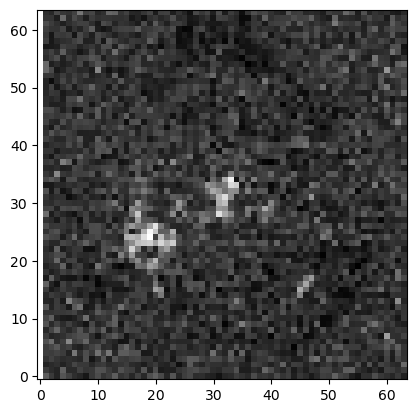

In [49]:
fig, axes = pyplot.subplots(1)
image_plot = axes.imshow(corr_map.T,
                        origin="lower",
                        cmap="grey")

In [50]:
# with filter
background_threshold = 250
for x in range(corr_map.shape[0]):
    for y in range(corr_map.shape[1]):
        time_series = fmri_data[x,y,z, :]
        if numpy.mean(time_series) < background_threshold: 
            corr_map[x, y] = 0
            continue
        cross = scipy.signal.correlate(
            normalise(time_series), 
            normalise(signal), 
            mode="same")
        corr_map[x,y] = numpy.max(cross)

In [51]:
brain = numpy.mean(fmri_data[:,:,z,:], axis = -1)

In [52]:
overlap_map = numpy.copy(corr_map)

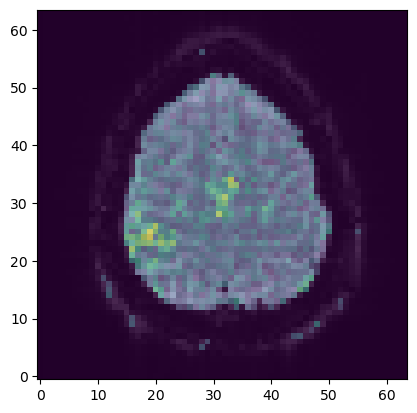

In [53]:
fig, axes = pyplot.subplots(1)
axes.imshow(brain.T,origin="lower",cmap="grey")
axes.imshow(overlap_map.T,origin="lower",cmap="viridis", alpha = 0.5) 
#overlap fMRI to the 'brain' with adapting transperancy

## Checking my spacemed function

In [55]:
import spacemed
corr_map1 = numpy.zeros(fmri.shape[:2])

In [56]:
background_threshold = 250
for x in range(corr_map.shape[0]):
    for y in range(corr_map.shape[1]):
        time_series = fmri_data[x,y,z, :]
        if numpy.mean(time_series) < background_threshold: 
            corr_map1[x, y] = 0
            continue
        cross,lag,p = spacemed.fmriCross(signal, fmri_data, (x,y,z))
        corr_map1[x,y] = numpy.max(cross)

In [60]:
print(lag, p)

[-40 -39 -38 -37 -36 -35 -34 -33 -32 -31 -30 -29 -28 -27 -26 -25 -24 -23
 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5
  -4  -3  -2  -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13
  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31
  32  33  34  35  36  37  38  39] 30


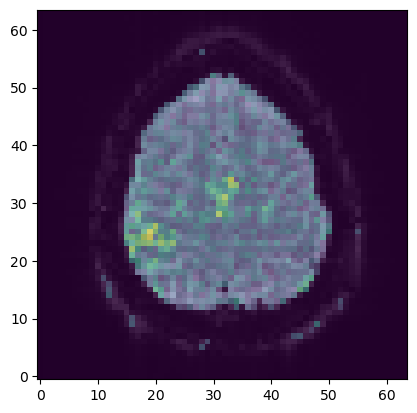

In [61]:
brain = numpy.mean(fmri_data[:,:,z,:], axis = -1)
overlap_map = numpy.copy(corr_map1)
    
fig, axes = pyplot.subplots(1)
axes.imshow(brain.T,origin="lower",cmap="grey")
axes.imshow(overlap_map.T,origin="lower",cmap="viridis", alpha = 0.5) 